# NB05 — Forecast & Konversi ISPU

Membuat forecast 24 jam ke depan (8 titik, setiap 3 jam) untuk 5 sensor, lalu mengubahnya menjadi ISPU.

**Input:** data mentah `data/raw/`, model `models/rf_multioutput/` (hasil NB04)
**Output:** `outputs/forecast/` (forecast terbaru, riwayat forecast, grafik)

Semua logika ada di **`src/pipeline.py`**, sehingga notebook ini dan script terjadwal
**`src/forecast.py`** memakai kode yang sama persis.

Setiap cell diberi kode `[NB05-Cxx]` dan diakhiri dengan `✓ [NB05-Cxx] selesai`.

### Cara menghitung ISPU
- Batas konsentrasi mengikuti **Permen LHK No. 14/2020**.
- Sistem di database menghitung ISPU dari **rata-rata 24 jam terakhir** setiap parameter (dicek di NB05-C09).
  Forecast ISPU memakai aturan yang sama: rata-rata 24 jam = data aktual sebelum origin + nilai forecast setelah origin.
- **HC** (kolom `HEDRO`) tidak di-forecast; bagian setelah origin memakai rata-rata HC 24 jam terakhir.

> **Asumsi zona waktu:** WITA = jam database − 8 jam.

In [ ]:
# ============================================================
# [NB05-C01] SETUP
# ============================================================

from pathlib import Path
import importlib
import json
import subprocess
import sys
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

warnings.filterwarnings("ignore")

ROOT = Path("..").resolve()
sys.path.insert(0, str(ROOT / "src"))

import pipeline as pl
importlib.reload(pl)   # agar perubahan di src/pipeline.py langsung terpakai

RAW_DIR = ROOT / "data" / "raw"
PROCESSED_DIR = ROOT / "data" / "processed"
MODEL_DIR = ROOT / "models" / "rf_multioutput"
OUTPUT_DIR = ROOT / "outputs" / "forecast"
CHART_DIR = OUTPUT_DIR / "charts"
CHART_DIR.mkdir(parents=True, exist_ok=True)

with open(PROCESSED_DIR / "model_config.json", encoding="utf-8") as f:
    config = json.load(f)

assert (MODEL_DIR / "metadata.json").exists(), "Jalankan NB04 dulu. Model tidak ditemukan."

# Warna grafik
COLOR_ACTUAL = "#2a78d6"
COLOR_FORECAST = "#eb6834"
COLOR_TEXT = "#52514e"
COLOR_GRID = "#e4e3df"

print("Folder project :", ROOT)
print("Sensor         :")
for sensor, lokasi in pl.SENSOR_LOCATIONS.items():
    print(f"  {sensor}  {lokasi}")

print("\n✓ [NB05-C01] selesai")

Folder project : D:\Kuliah\KP\forecast-ispu
Sensor         :
  PH10P0001  Plaza Seremoni
  PH14P0002  Wonotirto
  PH14P0003  Senipah
  PH14P0004  Muara Jawa Tengah
  PH20P0001  Plaza Bhineka

✓ [NB05-C01] selesai


In [ ]:
# ============================================================
# [NB05-C02] DATA MENTAH → DATA PER JAM
# ============================================================
# Di sistem produksi, pl.load_raw_tables() diganti dengan query ke database.

ispu_raw, weather_raw = pl.load_raw_tables(RAW_DIR / "ispu.csv", RAW_DIR / "ispu_weather.csv")
hourly = pl.build_hourly(ispu_raw, weather_raw)

print("Tabel ispu         :", ispu_raw.shape)
print("Tabel ispu_weather :", weather_raw.shape)
print("Data per jam       :", hourly.shape)
print("Data terakhir (jam database):", hourly["datetime_db"].max())

print("\n✓ [NB05-C02] selesai")

Tabel ispu         : (231440, 15)
Tabel ispu_weather : (170832, 16)
Data per jam       : (28295, 23)
Data terakhir (jam database): 2026-09-21 17:00:00

✓ [NB05-C02] selesai


In [ ]:
# ============================================================
# [NB05-C03] CEK: DATA PER JAM SAMA DENGAN HASIL NB00
# ============================================================

nb00 = pd.read_csv(PROCESSED_DIR / "hourly_per_sensor.csv", parse_dates=["datetime_db"])
value_cols = [c for c in nb00.columns if c not in [pl.DEVICE_COL, "datetime_db"]]

assert list(hourly.columns) == list(nb00.columns), "Kolom berbeda dengan NB00"
assert len(hourly) == len(nb00), "Jumlah baris berbeda dengan NB00"
assert (hourly[[pl.DEVICE_COL, "datetime_db"]].values == nb00[[pl.DEVICE_COL, "datetime_db"]].values).all()
assert np.allclose(hourly[value_cols].astype(float), nb00[value_cols].astype(float), equal_nan=True)

print(f"✓ {len(hourly)} baris × {len(value_cols)} kolom identik dengan hasil NB00")

print("\n✓ [NB05-C03] selesai")

✓ 28295 baris × 21 kolom identik dengan hasil NB00

✓ [NB05-C03] selesai


In [ ]:
# ============================================================
# [NB05-C04] FITUR & CEK: SAMA DENGAN HASIL NB03
# ============================================================

models, metadata = pl.load_models(MODEL_DIR)
HORIZONS = metadata["horizons"]
FEATURE_COLS = metadata["feature_cols"]

feat = pl.build_features(hourly, config, HORIZONS)

nb03 = pd.read_csv(PROCESSED_DIR / "model_dataset.csv", parse_dates=["origin_time"])
check = nb03[[pl.DEVICE_COL, "origin_time"] + FEATURE_COLS].merge(
    feat[[pl.DEVICE_COL, "origin_time"] + FEATURE_COLS],
    on=[pl.DEVICE_COL, "origin_time"],
    suffixes=("_nb03", "_pipeline"),
)
different = [
    c for c in FEATURE_COLS
    if not np.allclose(check[f"{c}_nb03"].astype(float), check[f"{c}_pipeline"].astype(float),
                       equal_nan=True, atol=1e-4)
]

assert len(check) == len(nb03), "Baris tidak cocok dengan NB03"
assert not different, f"Fitur berbeda dengan NB03: {different}"

print(f"✓ {len(check)} baris × {len(FEATURE_COLS)} fitur identik dengan hasil NB03")
print("\nModel yang dipakai:")
for p in metadata["pollutants"]:
    print(f"  RF_{p:<5} cara {metadata['target_mode'][p]}")

print("\n✓ [NB05-C04] selesai")

✓ 17930 baris × 115 fitur identik dengan hasil NB03

Model yang dipakai:
  RF_PM25  cara koreksi
  RF_PM10  cara koreksi
  RF_CO    cara koreksi
  RF_O3    cara langsung
  RF_SO2   cara langsung
  RF_NO2   cara langsung

✓ [NB05-C04] selesai


In [ ]:
# ============================================================
# [NB05-C05] PILIH ORIGIN FORECAST
# ============================================================
# Origin = jam grid terbaru (02, 05, 08, ... WITA) yang datanya sudah lengkap.
# Untuk memilih origin lain, isi manual, contoh: ORIGIN = pd.Timestamp("2026-09-20 14:00")

ORIGIN = pl.latest_grid_origin(feat, metadata)

rows = feat[feat["origin_time"] == ORIGIN].set_index(pl.DEVICE_COL)
status = pd.DataFrame({
    "lokasi": [pl.SENSOR_LOCATIONS[s] for s in rows.index],
    "data_terakhir_WITA": rows["hour_wita"] + pd.Timedelta(minutes=59),
    "fitur_lengkap": rows[FEATURE_COLS].notna().all(axis=1),
})

print(f"Origin forecast : {ORIGIN} WITA")
print(f"Titik forecast  : {[str((ORIGIN + pd.Timedelta(hours=h)).strftime('%d/%m %H:%M')) for h in HORIZONS]}")
print()
print(status.to_string())

print("\n✓ [NB05-C05] selesai")

Origin forecast : 2026-09-21 08:00:00 WITA
Titik forecast  : ['21/09 11:00', '21/09 14:00', '21/09 17:00', '21/09 20:00', '21/09 23:00', '22/09 02:00', '22/09 05:00', '22/09 08:00']

                           lokasi  data_terakhir_WITA  fitur_lengkap
ispu_device_id                                                      
PH10P0001          Plaza Seremoni 2026-09-21 07:59:00           True
PH14P0002               Wonotirto 2026-09-21 07:59:00           True
PH14P0003                 Senipah 2026-09-21 07:59:00           True
PH14P0004       Muara Jawa Tengah 2026-09-21 07:59:00           True
PH20P0001           Plaza Bhineka 2026-09-21 07:59:00           True

✓ [NB05-C05] selesai


In [ ]:
# ============================================================
# [NB05-C06] BUAT FORECAST
# ============================================================

forecast, skipped = pl.predict_forecast(feat, ORIGIN, models, metadata)

print(f"Jumlah nilai forecast: {len(forecast)} "
      f"({forecast['sensor'].nunique()} sensor × {forecast['polutan'].nunique()} polutan × {len(HORIZONS)} titik)")

if not skipped.empty:
    print("\nDilewati:")
    print(skipped.to_string(index=False))

example = forecast[forecast["sensor"] == "PH14P0003"].pivot_table(
    index="polutan", columns="forecast_time", values="konsentrasi_3jam"
)
example.columns = [t.strftime("%d/%m %H:%M") for t in example.columns]
print("\nContoh: forecast Senipah (PH14P0003), rata-rata 3 jam (µg/m³)")
print(example.round(2).to_string())

print("\n✓ [NB05-C06] selesai")

Jumlah nilai forecast: 240 (5 sensor × 6 polutan × 8 titik)

Contoh: forecast Senipah (PH14P0003), rata-rata 3 jam (µg/m³)
         21/09 11:00  21/09 14:00  21/09 17:00  21/09 20:00  21/09 23:00  22/09 02:00  22/09 05:00  22/09 08:00
polutan                                                                                                        
CO            677.76       425.63       432.28       430.68       742.71       764.55       637.42       859.29
NO2            21.42         7.40        10.26        32.86        42.30        40.63        41.53        41.32
O3             46.90        63.59        66.63        63.27        52.98        44.36        40.07        36.18
PM10          103.43        53.47        47.81        50.40       101.22       122.95       107.96       108.51
PM25           57.98        28.82        24.69        26.03        52.80        60.30        54.24        53.29
SO2             0.01         0.03         0.01         0.00         0.00         0.01        

In [ ]:
# ============================================================
# [NB05-C07] SANITY CHECK FORECAST
# ============================================================

n_expected = forecast["sensor"].nunique() * len(metadata["pollutants"]) * len(HORIZONS)

checks = {
    "jumlah nilai sesuai": len(forecast) == n_expected,
    "tidak ada NaN": forecast["konsentrasi_3jam"].notna().all(),
    "tidak ada nilai negatif": (forecast["konsentrasi_3jam"] >= 0).all(),
    "tidak ada duplikat": not forecast.duplicated(["sensor", "polutan", "horizon_jam"]).any(),
    "semua titik di jam grid": forecast["forecast_time"].dt.hour.isin(metadata["grid_hours_wita"]).all(),
}
for name, ok in checks.items():
    print(f"{'✓' if ok else '✗'} {name}")

# Bandingkan rentang forecast dengan rentang data historis (titik grafik 3 jam)
hist_range = feat.groupby(pl.DEVICE_COL)[[f"{p}_block3h" for p in metadata["pollutants"]]].quantile(0.99)
hist_range.columns = metadata["pollutants"]
fc_max = forecast.pivot_table(index="sensor", columns="polutan", values="konsentrasi_3jam", aggfunc="max")
print("\nNilai forecast tertinggi vs persentil 99 data historis:")
print(pd.concat({"forecast_max": fc_max, "historis_p99": hist_range}, axis=1).round(1).to_string())

assert all(checks.values()), "Ada sanity check yang gagal"

print("\n✓ [NB05-C07] selesai")

✓ jumlah nilai sesuai
✓ tidak ada NaN
✓ tidak ada nilai negatif
✓ tidak ada duplikat
✓ semua titik di jam grid

Nilai forecast tertinggi vs persentil 99 data historis:
          forecast_max                                historis_p99                                 
                    CO   NO2    O3   PM10   PM25  SO2         PM25   PM10      CO    O3   SO2   NO2
PH10P0001        758.7  61.8  13.7   75.8   42.0  6.8         38.7   68.7   688.1  14.0  12.9  68.8
PH14P0002       1828.7  33.3  51.5  313.5  169.7  6.9        233.5  331.5  2761.2  58.7  31.5  47.5
PH14P0003        859.3  42.3  66.6  123.0   60.3  0.0         92.0  171.1   984.9  71.5   0.0  53.7
PH14P0004       2013.3  23.0  19.5  272.0  160.3  8.3        103.5  201.3   943.2  22.9   4.3  31.5
PH20P0001        875.4  18.2  75.7  104.4   60.1  4.4         59.3  124.8   780.8  95.4   8.0  23.7

✓ [NB05-C07] selesai


In [ ]:
# ============================================================
# [NB05-C08] RUMUS ISPU (PERMEN LHK NO. 14/2020)
# ============================================================

bp = pd.DataFrame(pl.ISPU_BREAKPOINTS, index=pl.ISPU_LEVELS)
bp.index.name = "ISPU"
print("Batas konsentrasi (µg/m³):")
print(bp.to_string())

print("\nKategori:")
lower = 0
for upper, name in pl.ISPU_CATEGORIES:
    upper_txt = "ke atas" if np.isinf(upper) else f"– {int(upper)}"
    print(f"  {lower:>3} {upper_txt:<8} {name}")
    lower = int(upper) + 1 if not np.isinf(upper) else lower

# Contoh: PM2.5 = 55.4 µg/m³ -> ISPU 100
assert round(float(pl.ispu_subindex(55.4, "PM25"))) == 100
assert pl.ispu_category(100) == "Sedang" and pl.ispu_category(101) == "Tidak Sehat"

print("\n✓ [NB05-C08] selesai")

Batas konsentrasi (µg/m³):
      PM10   PM25   SO2     CO    O3   NO2   HC
ISPU                                           
0        0    0.0     0      0     0     0    0
50      50   15.5    52   4000   120    80   45
100    150   55.4   180   8000   235   200  100
200    350  150.4   400  15000   400  1130  215
300    420  250.4   800  30000   800  2260  432
500    500  500.0  1200  45000  1000  3000  648

Kategori:
    0 – 50     Baik
   51 – 100    Sedang
  101 – 200    Tidak Sehat
  201 – 300    Sangat Tidak Sehat
  301 ke atas  Berbahaya

✓ [NB05-C08] selesai


In [ ]:
# ============================================================
# [NB05-C09] CEK RUMUS ISPU TERHADAP KOLOM AQI DI DATABASE
# ============================================================
# ISPU dihitung dari data historis (rata-rata 24 jam terakhir),
# lalu dibandingkan dengan kolom AQI yang dihitung sistem.

hist_ispu = pl.historical_ispu(feat)
cmp = hist_ispu.dropna(subset=["ISPU", "AQI"]).copy()
cmp["selisih"] = (cmp["ISPU"] - cmp["AQI"]).abs()
cmp["kategori_hitung"] = cmp["ISPU"].map(pl.ispu_category)
cmp["kategori_database"] = cmp["AQI"].map(pl.ispu_category)

print(f"Jumlah jam dibandingkan : {len(cmp)}")
print(f"Selisih ≤ 3 poin        : {(cmp['selisih'] <= 3).mean():.1%}")
print(f"Selisih ≤ 5 poin        : {(cmp['selisih'] <= 5).mean():.1%}")
print(f"Kategori sama           : {(cmp['kategori_hitung'] == cmp['kategori_database']).mean():.1%}")

print("\nPer sensor (kategori sama):")
print(cmp.groupby(pl.DEVICE_COL).apply(
    lambda d: f"{(d['kategori_hitung'] == d['kategori_database']).mean():.1%}"
).to_string())

print("\n✓ [NB05-C09] selesai")

Jumlah jam dibandingkan : 15140
Selisih ≤ 3 poin        : 95.2%
Selisih ≤ 5 poin        : 97.8%
Kategori sama           : 98.4%

Per sensor (kategori sama):
ispu_device_id
PH10P0001    99.5%
PH14P0002    97.9%
PH14P0003    98.3%
PH14P0004    98.5%
PH20P0001    98.0%

✓ [NB05-C09] selesai


In [ ]:
# ============================================================
# [NB05-C10] FORECAST ISPU
# ============================================================

ispu_fc = pl.forecast_ispu(feat, forecast, ORIGIN, HORIZONS)

table = ispu_fc.pivot_table(index="lokasi", columns="forecast_time", values="ISPU")
table.columns = [t.strftime("%d/%m %H:%M") for t in table.columns]

# ISPU aktual terakhir (sebelum origin) sebagai pembanding
last_actual = (
    hist_ispu[hist_ispu["origin_time"] == ORIGIN]
    .assign(lokasi=lambda d: d[pl.DEVICE_COL].map(pl.SENSOR_LOCATIONS))
    .set_index("lokasi")["ISPU"].round()
)
table.insert(0, "aktual (origin)", last_actual)

print("ISPU (rata-rata 24 jam, seperti dashboard):")
print(table.to_string())

print("\nKategori & polutan dominan:")
cat = ispu_fc.pivot_table(index="lokasi", columns="forecast_time",
                          values="kategori", aggfunc="first")
cat.columns = [t.strftime("%d/%m %H:%M") for t in cat.columns]
print(cat.to_string())
print("\nPolutan dominan:", ispu_fc.groupby("lokasi")["polutan_dominan"].agg(lambda s: s.mode()[0]).to_dict())

print("\n✓ [NB05-C10] selesai")

ISPU (rata-rata 24 jam, seperti dashboard):
                   aktual (origin)  21/09 11:00  21/09 14:00  21/09 17:00  21/09 20:00  21/09 23:00  22/09 02:00  22/09 05:00  22/09 08:00
lokasi                                                                                                                                    
Muara Jawa Tengah            125.0        126.0        127.0        128.0        129.0        131.0        135.0        131.0        125.0
Plaza Bhineka                 84.0         86.0         87.0         88.0         88.0         88.0         89.0         89.0         86.0
Plaza Seremoni                65.0         67.0         68.0         69.0         69.0         69.0         69.0         69.0         67.0
Senipah                       92.0         93.0         94.0         93.0         93.0         92.0         91.0         90.0         87.0
Wonotirto                    172.0        172.0        172.0        170.0        169.0        165.0        158.0        15

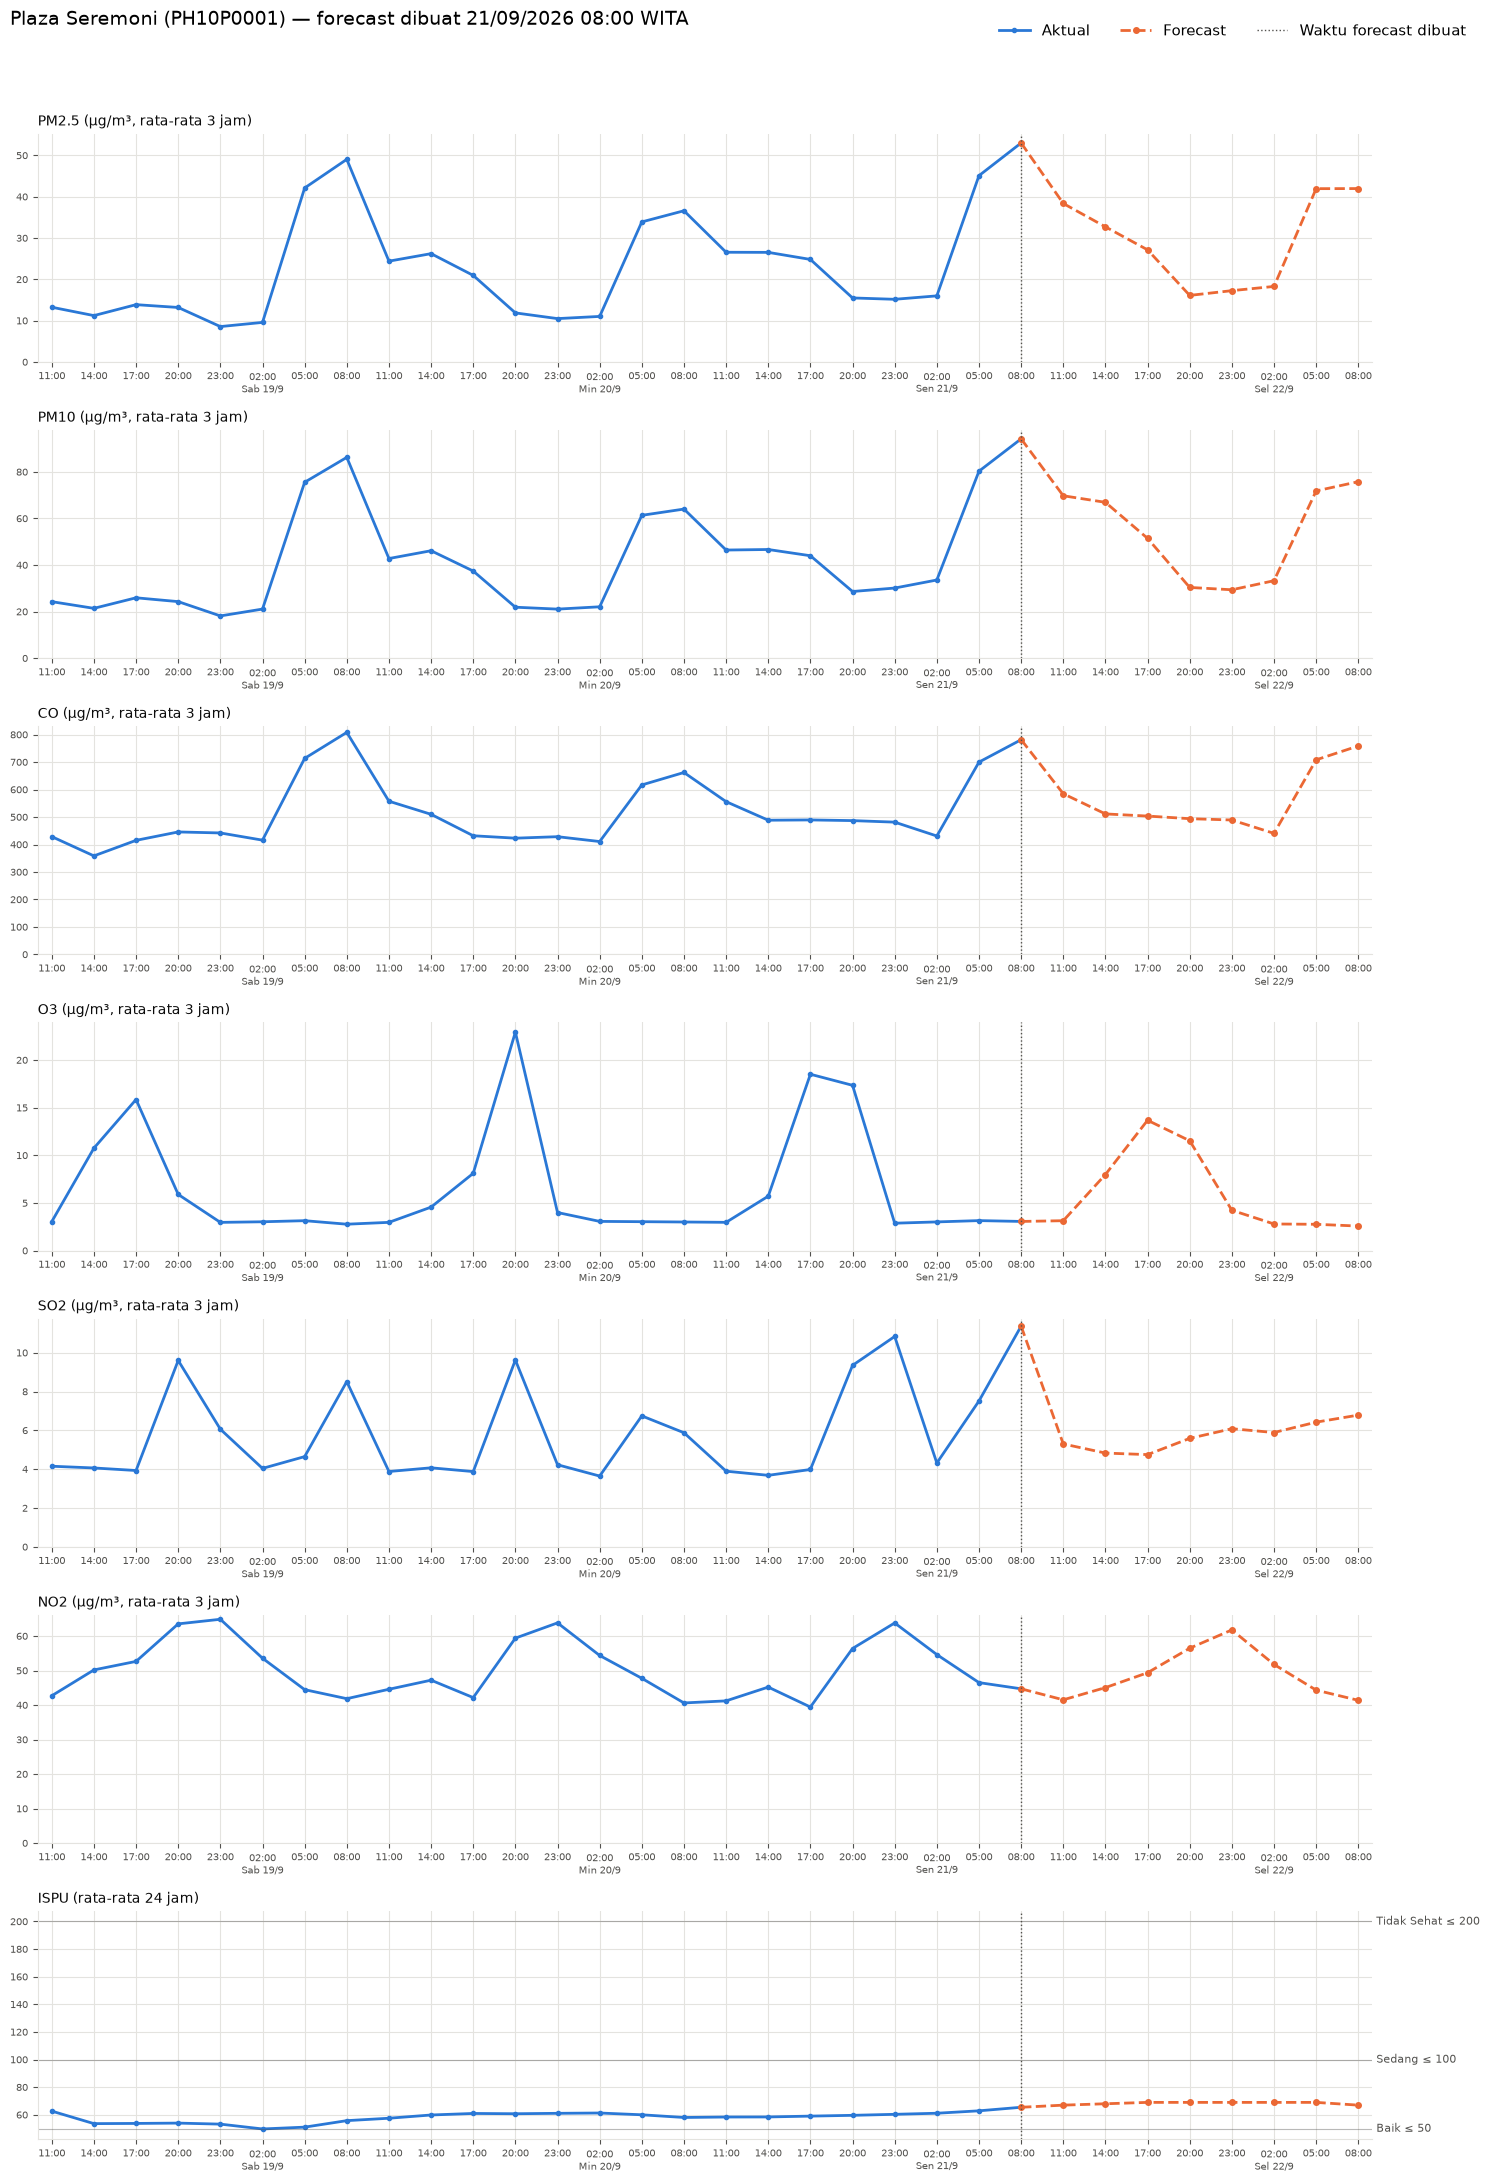

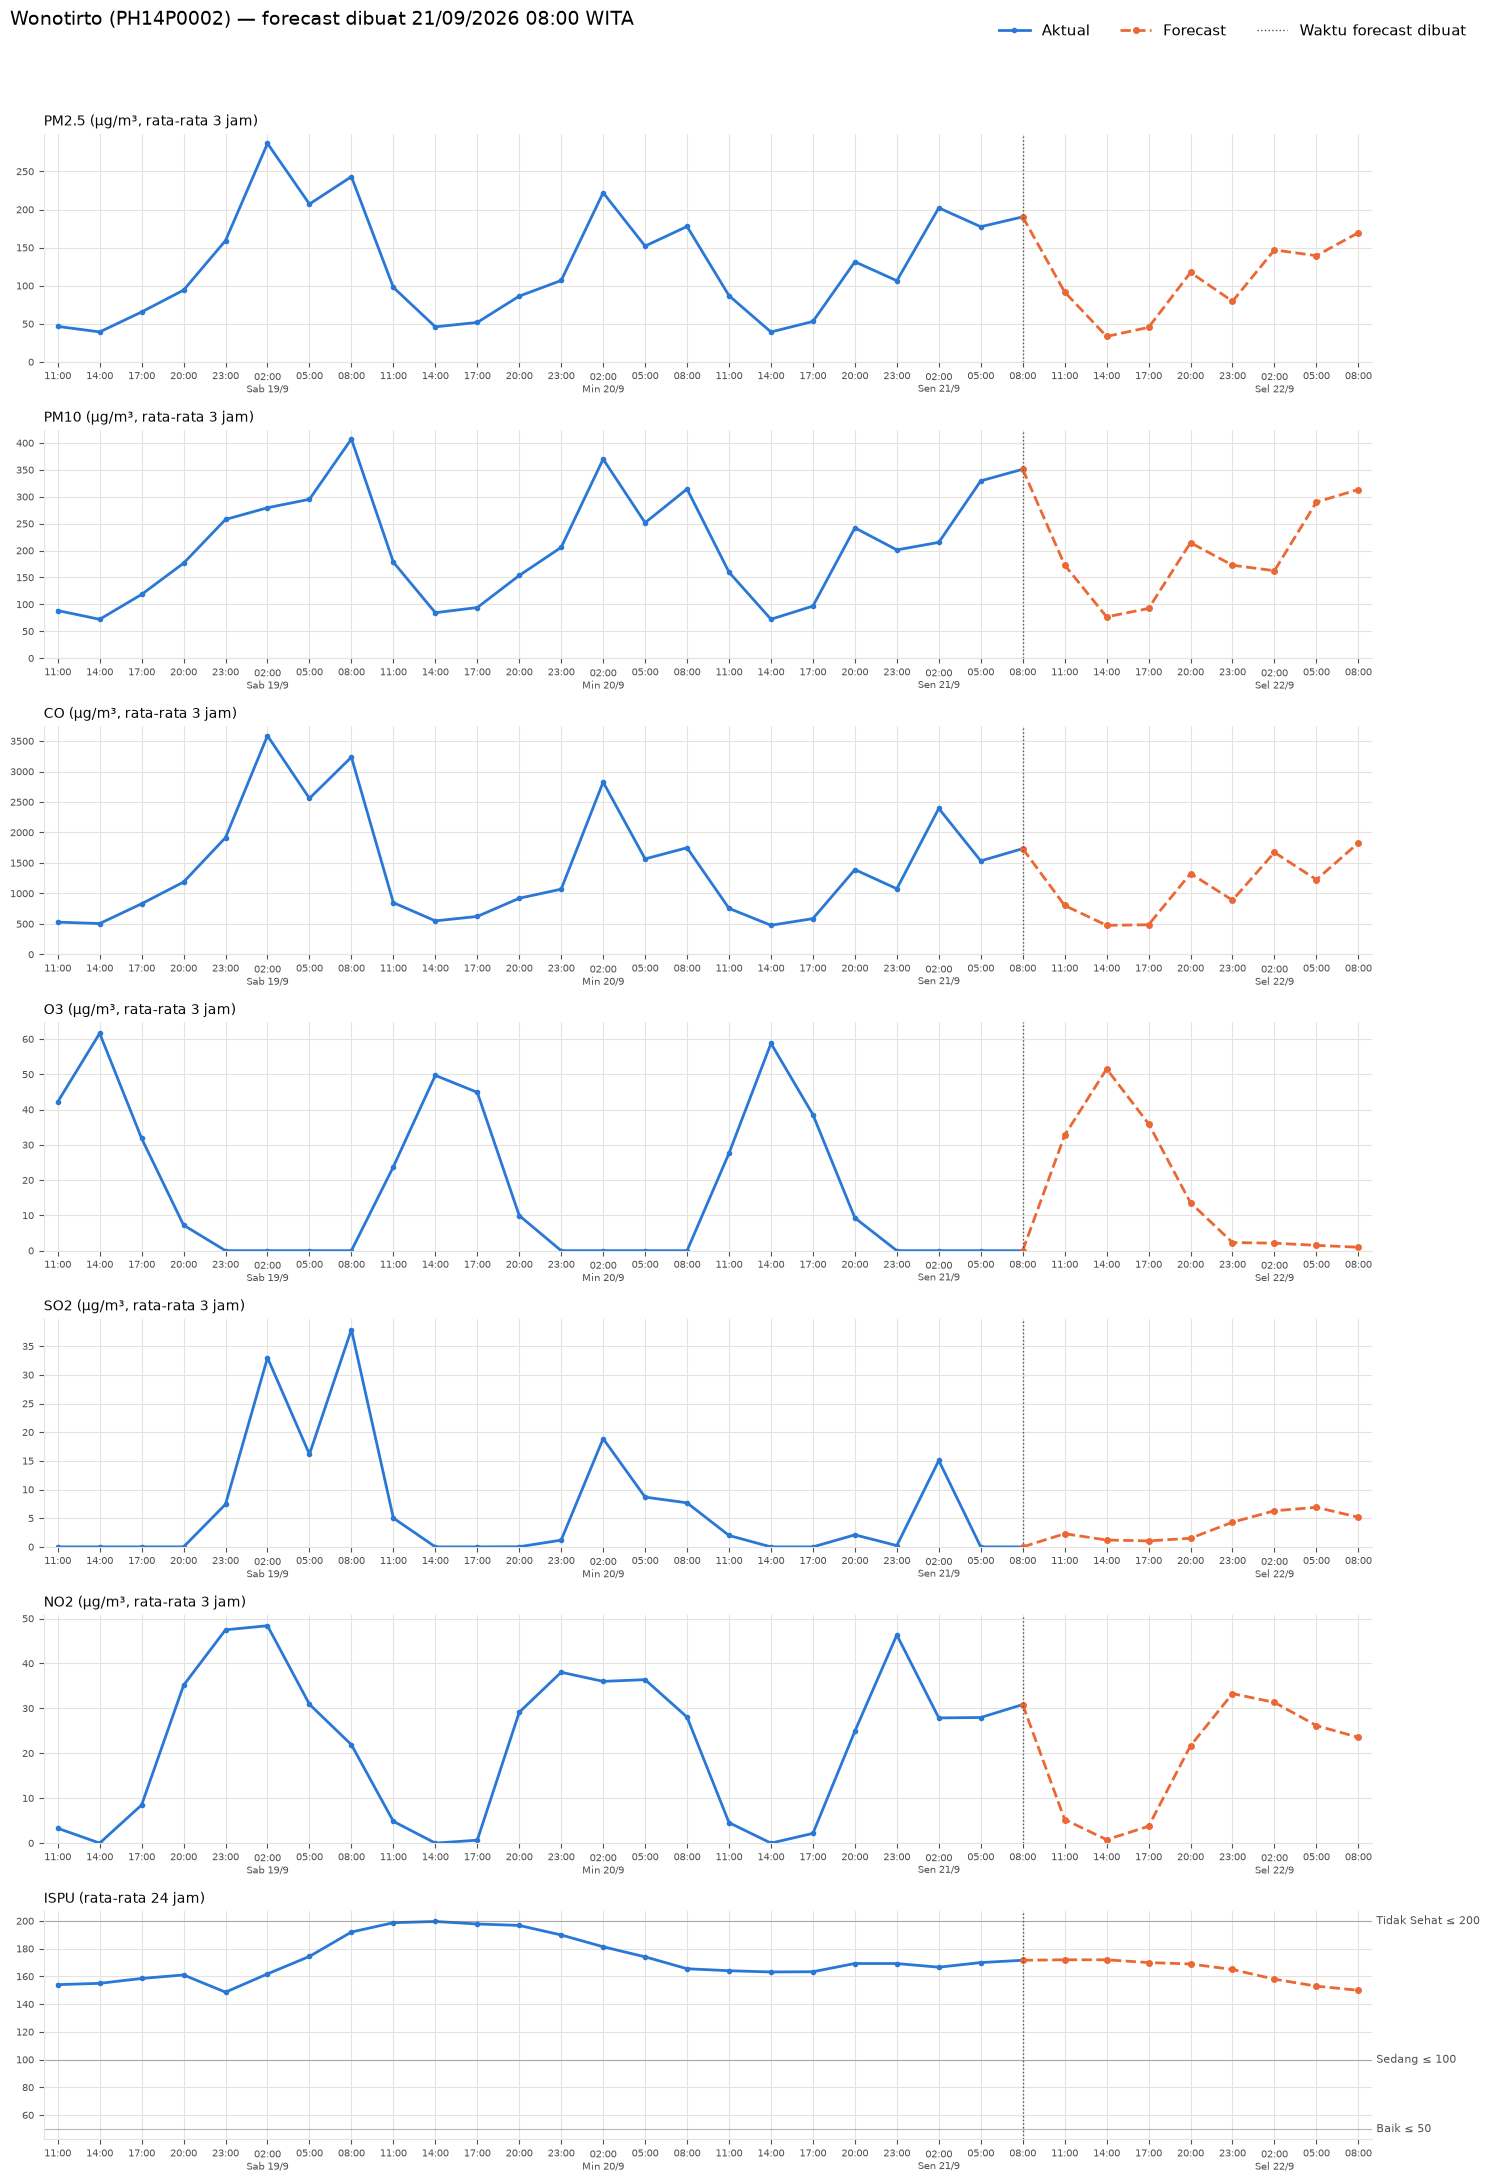

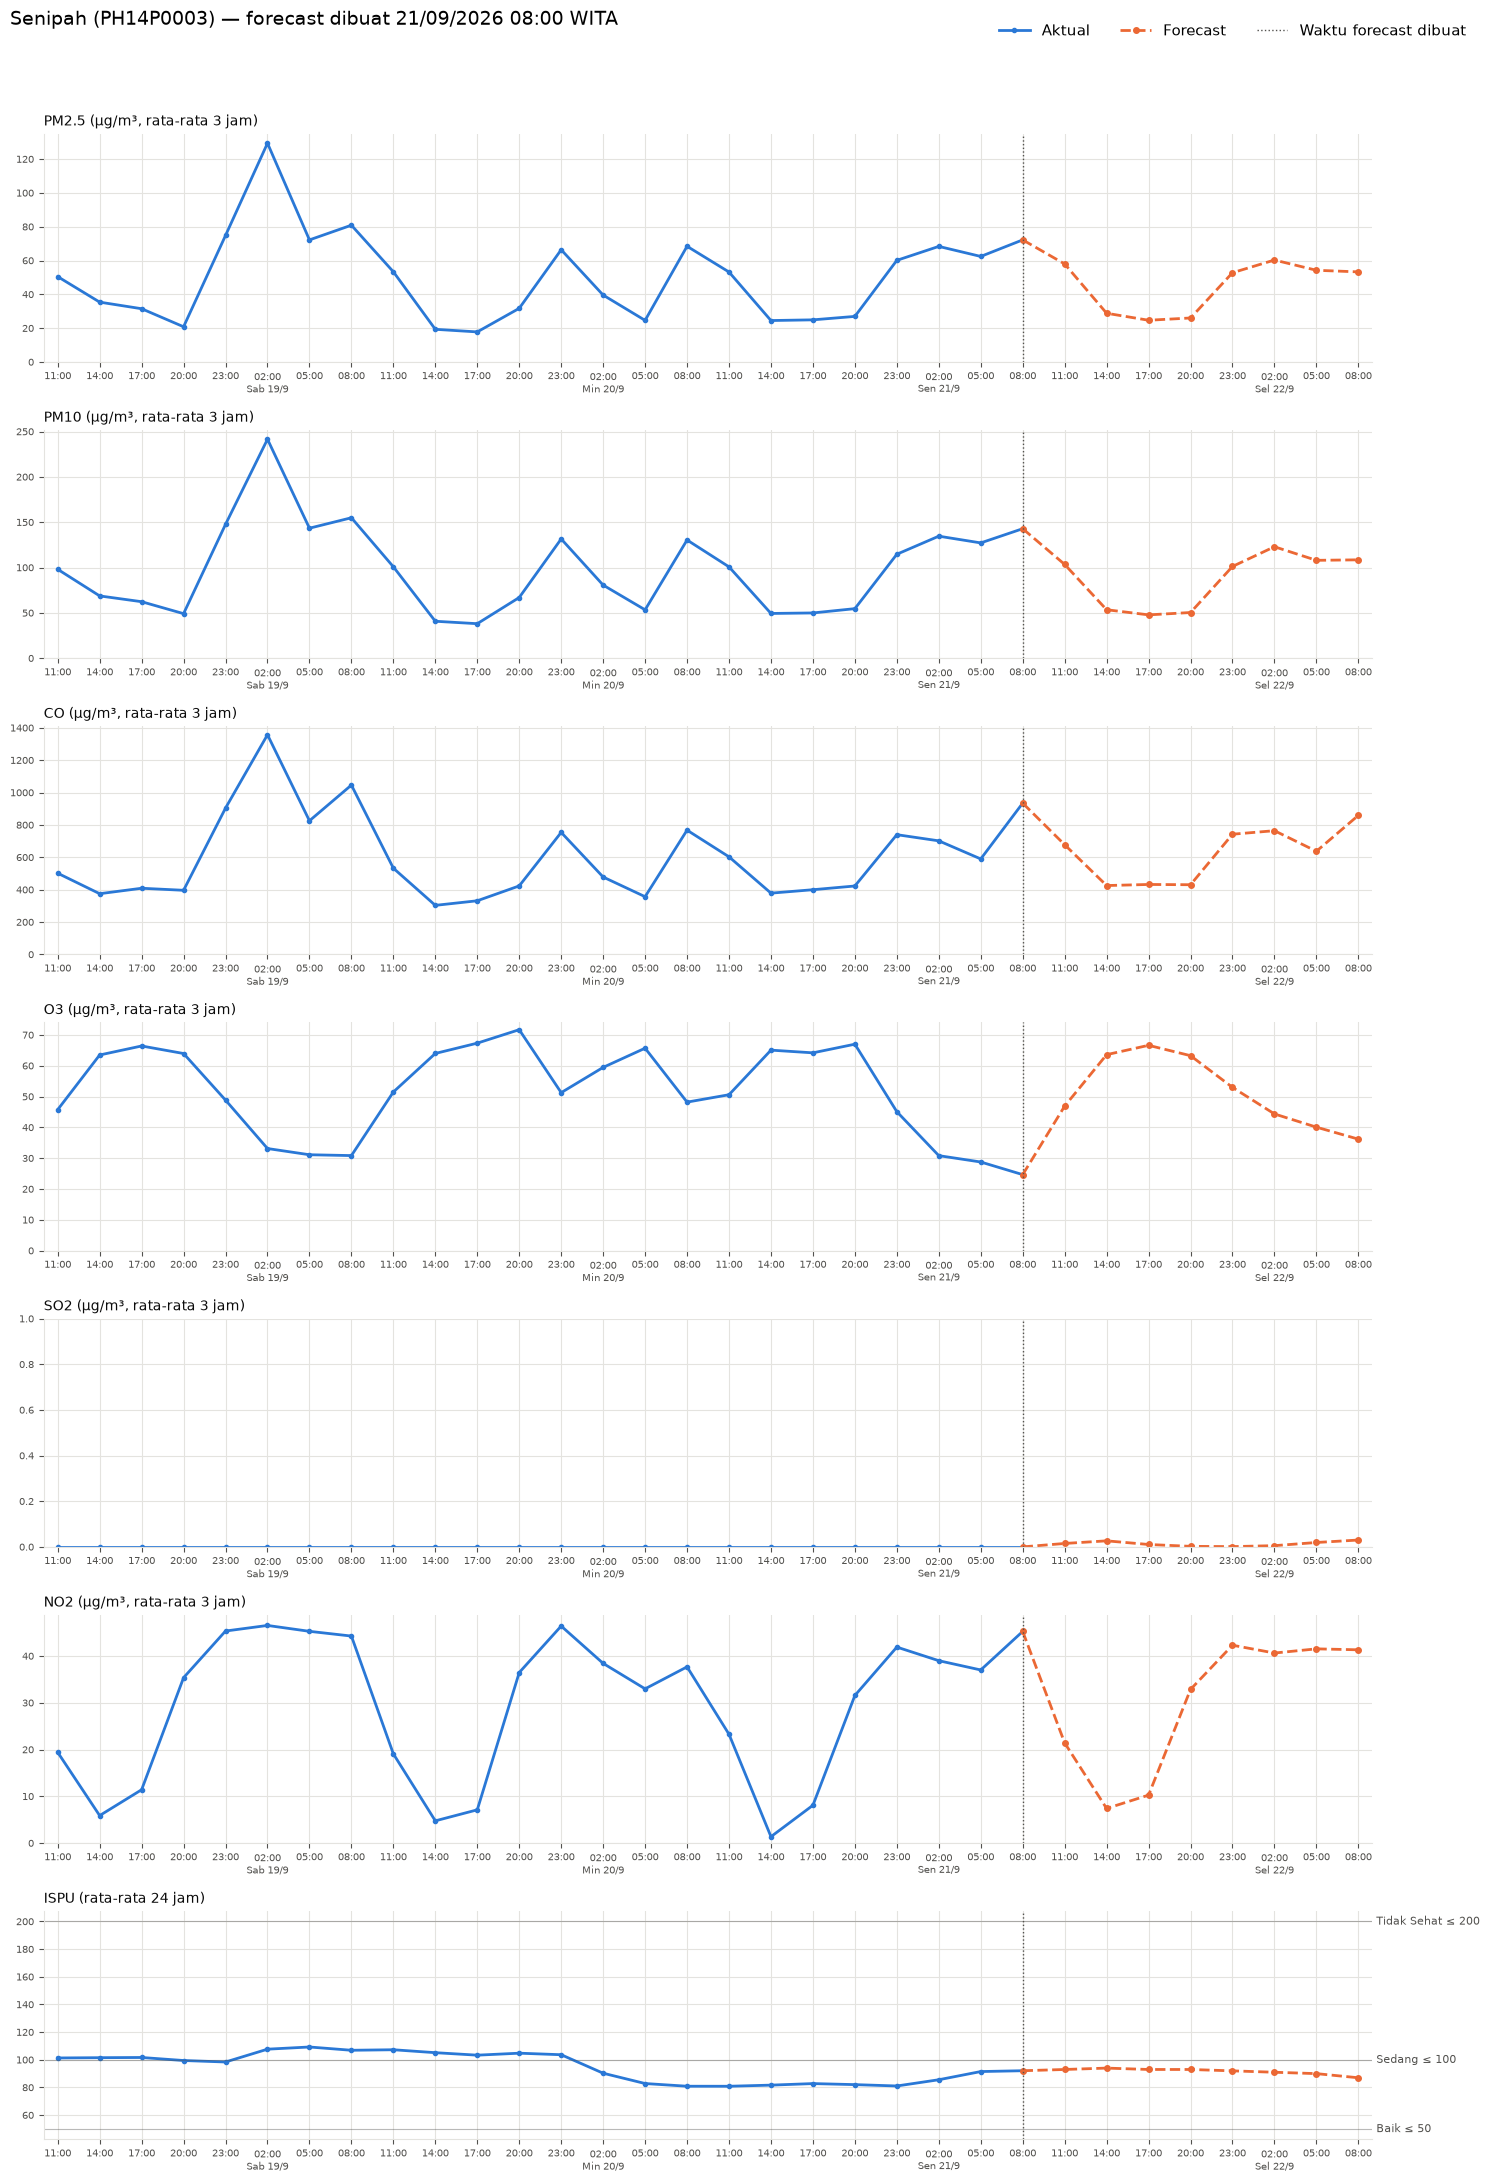

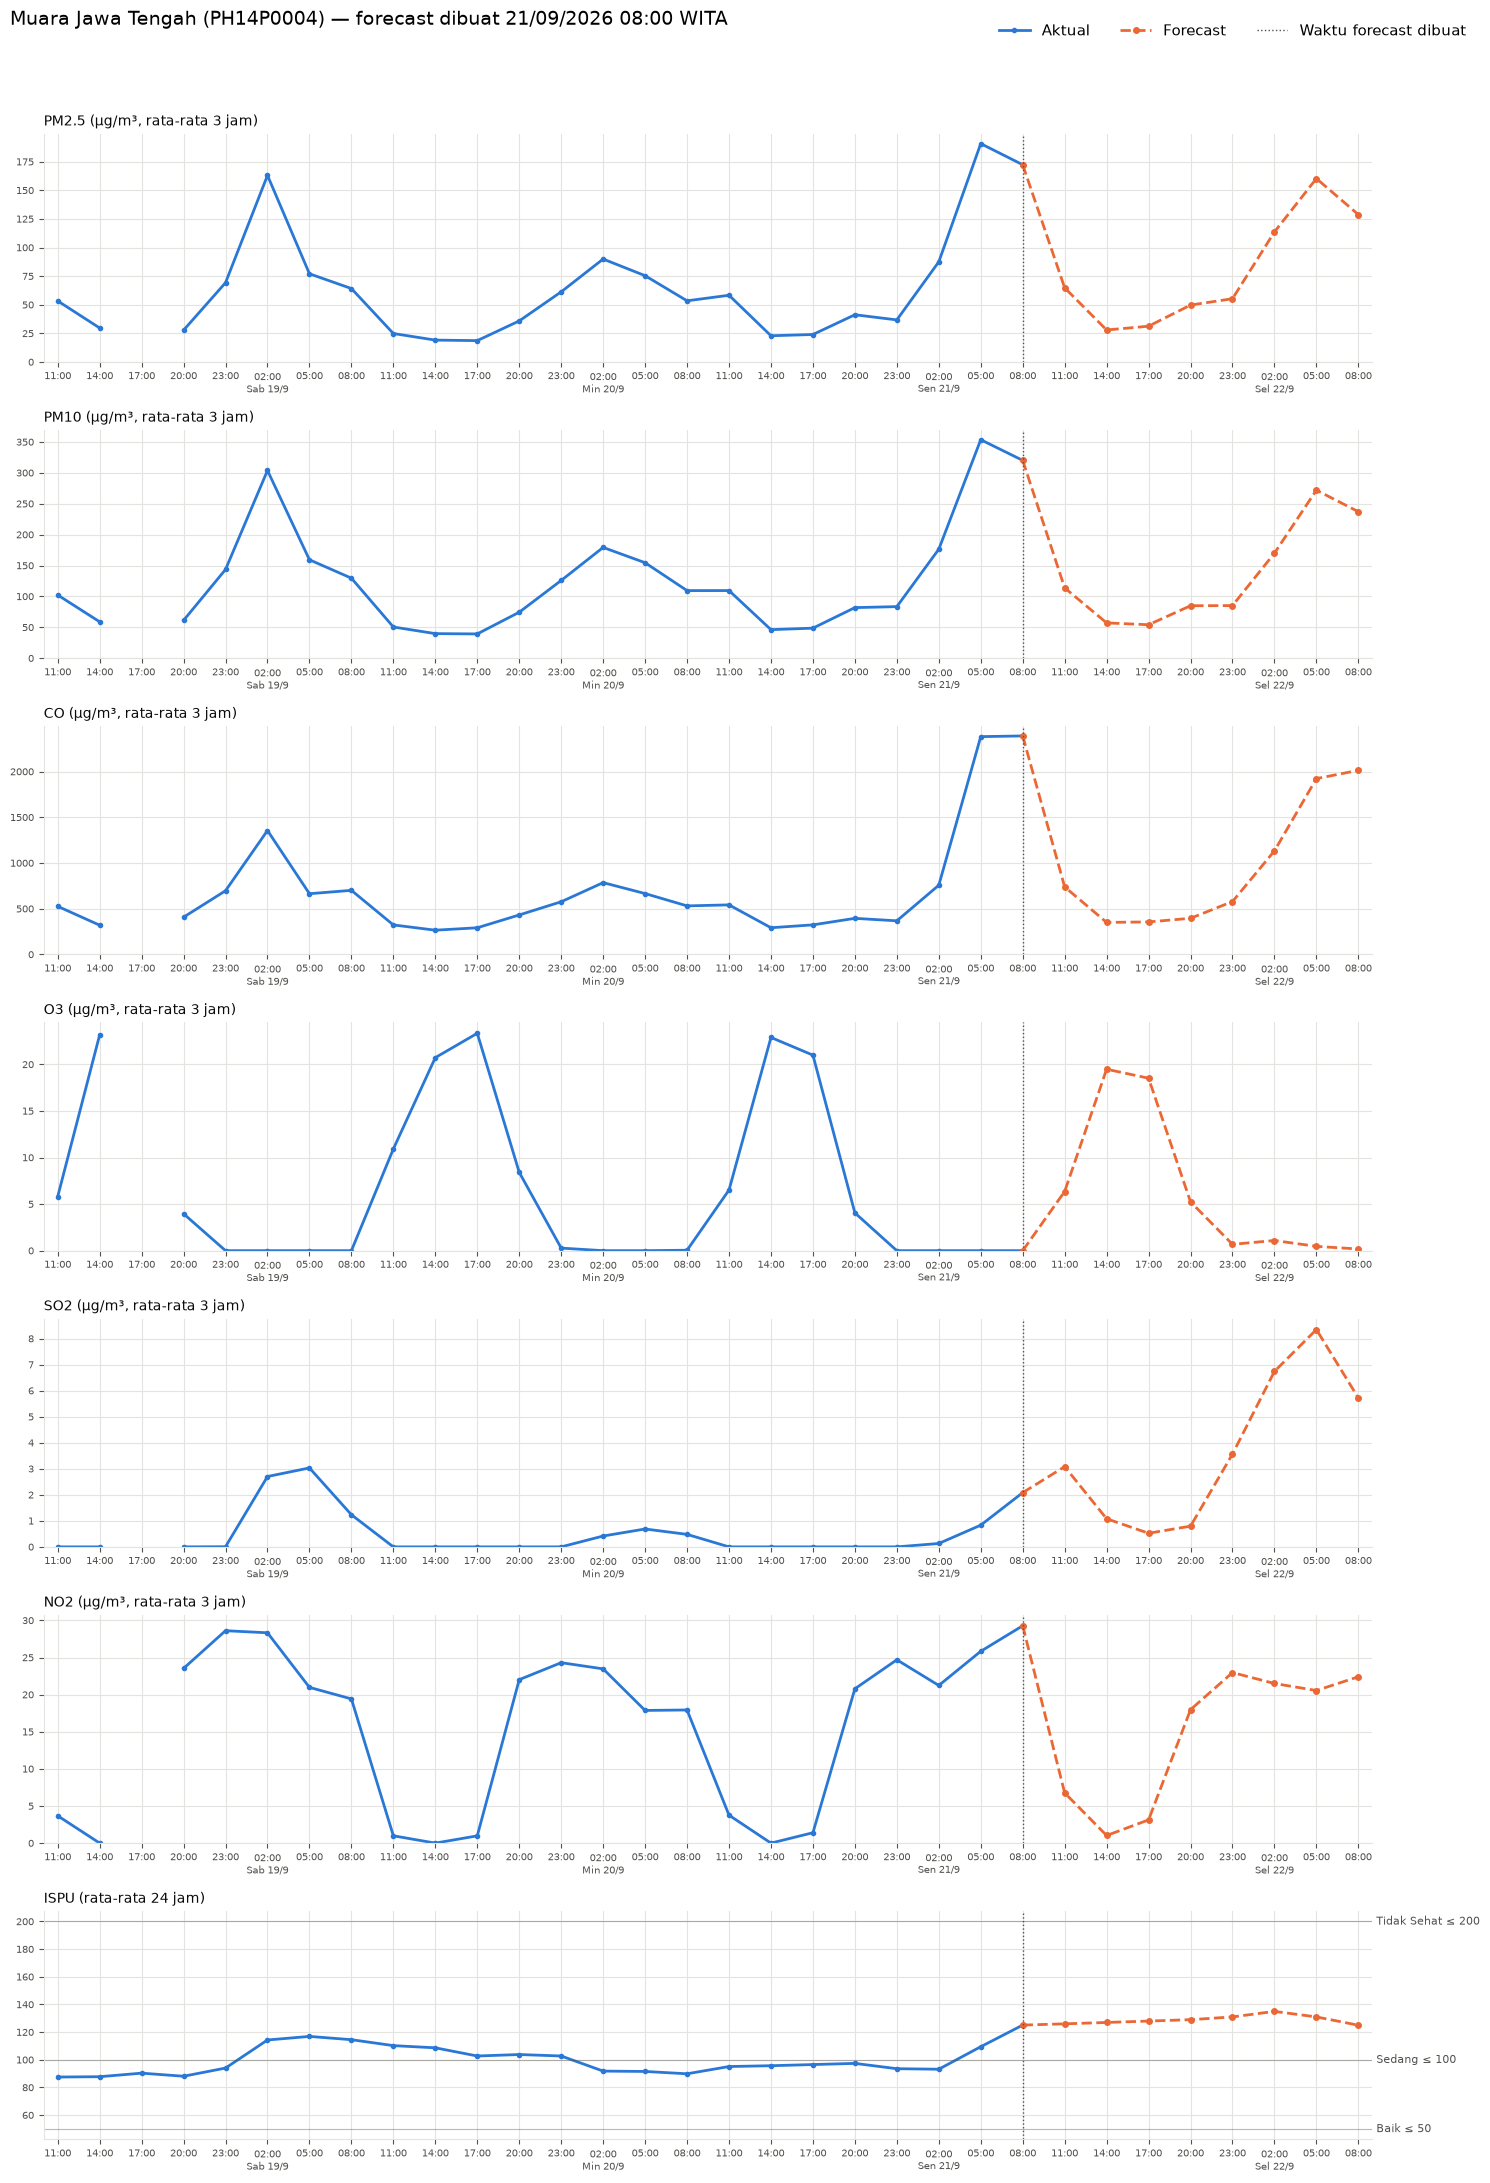

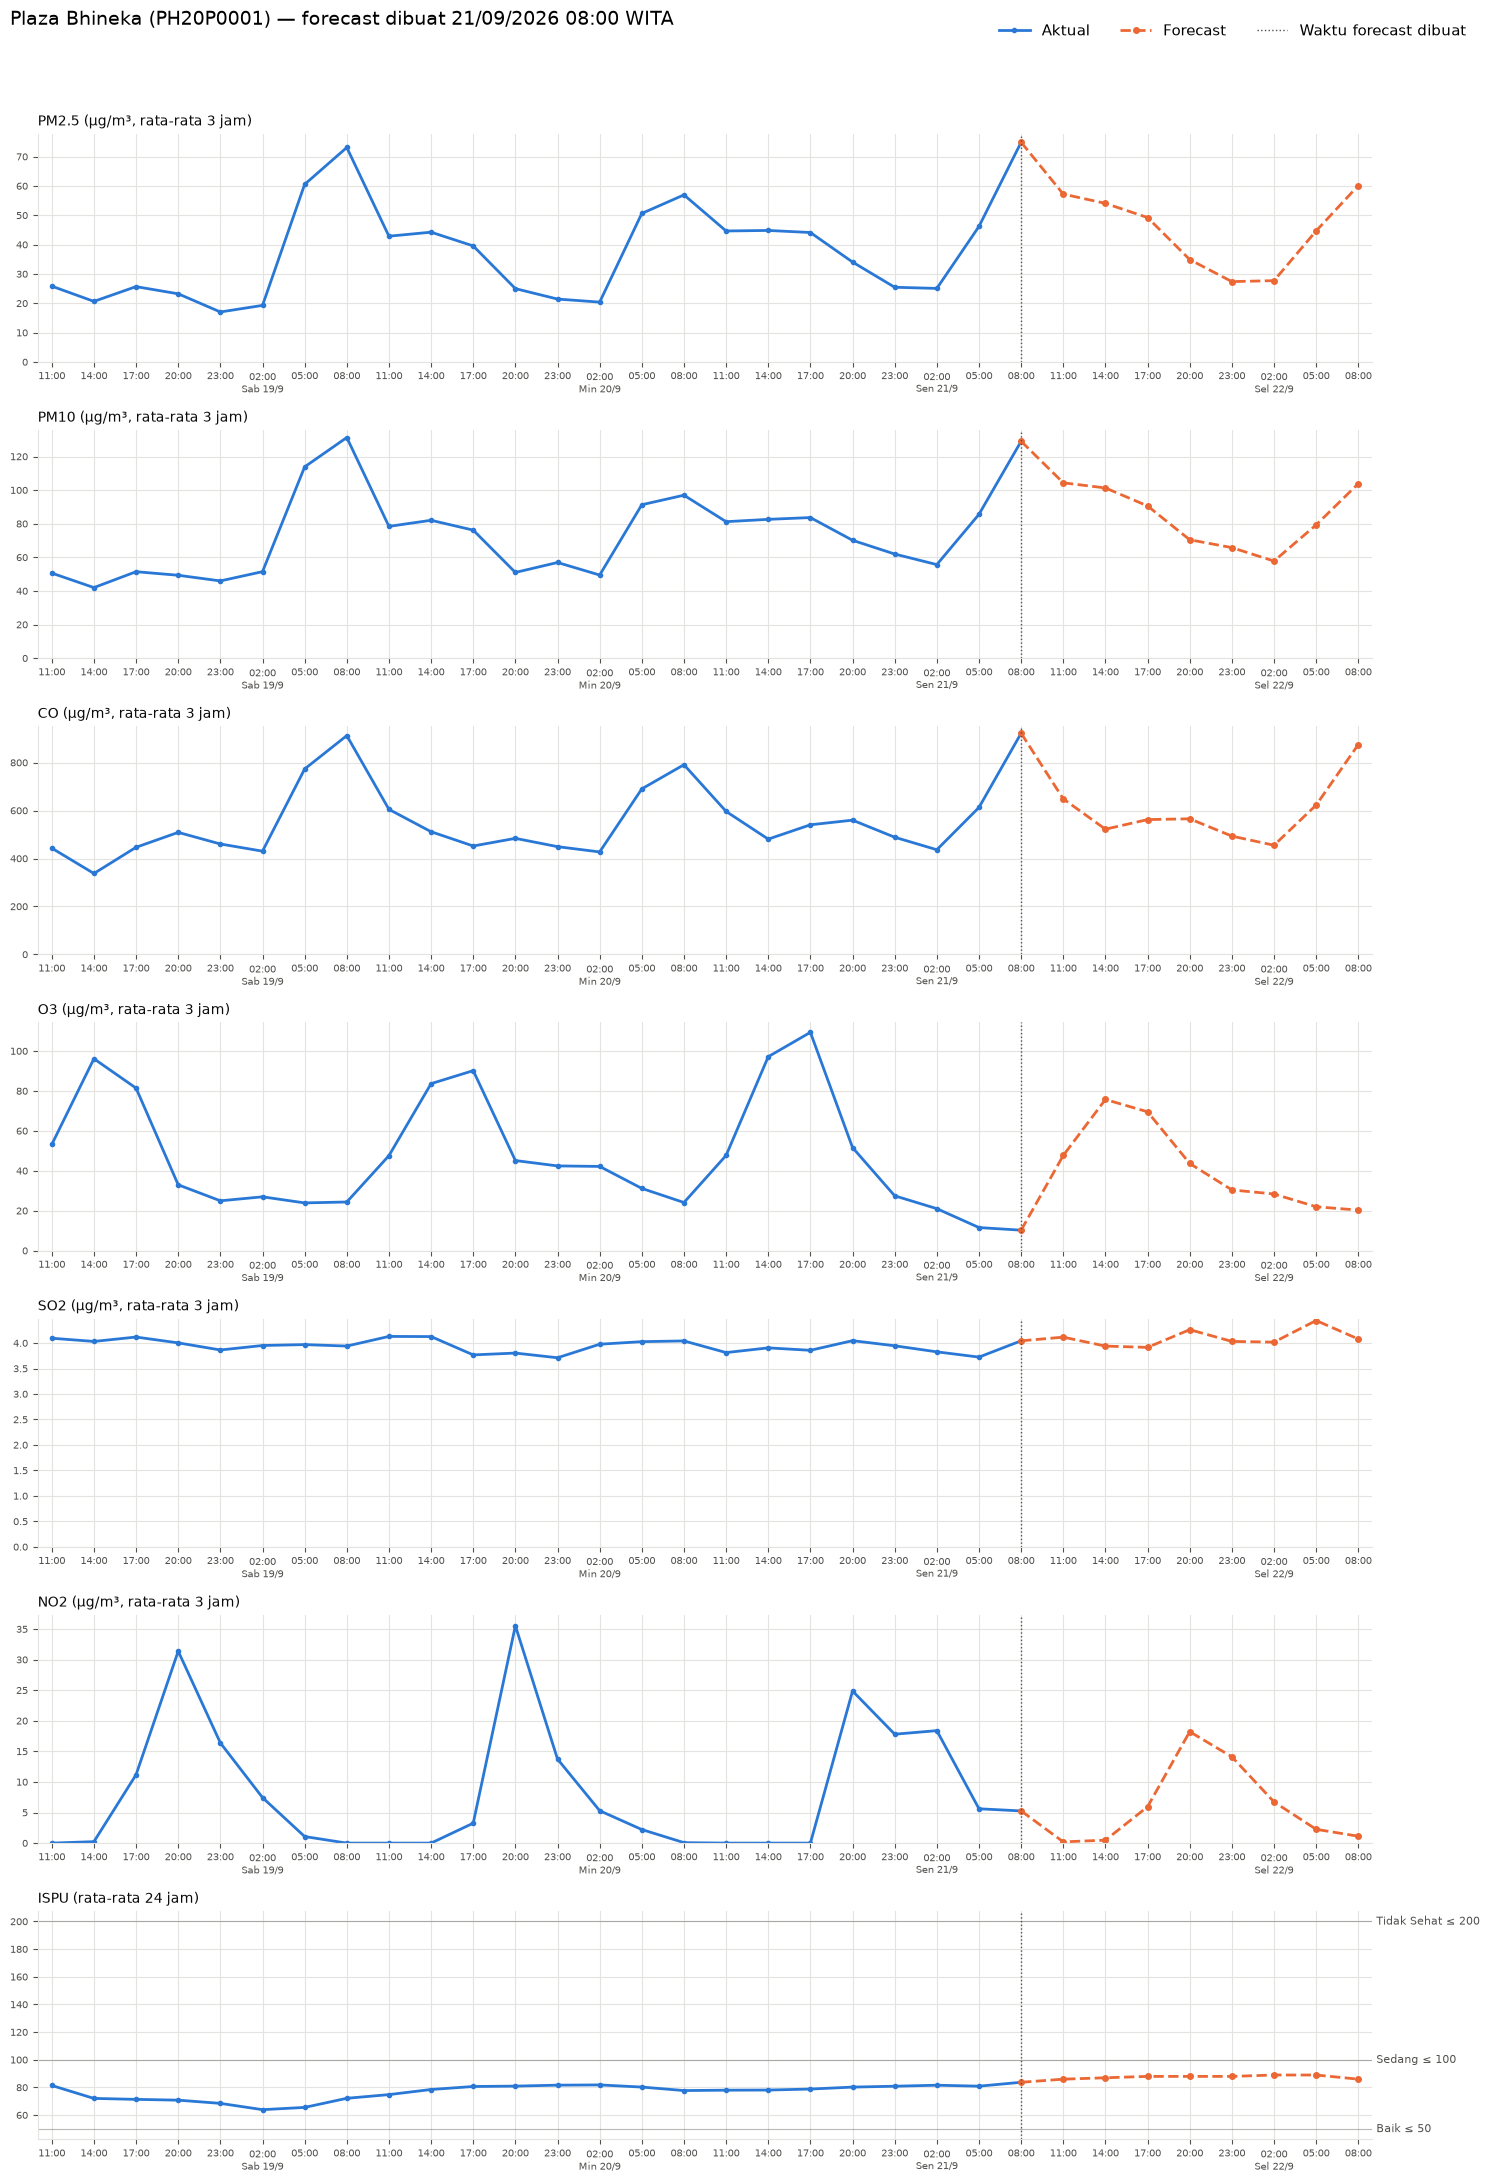

Grafik disimpan di: D:\Kuliah\KP\forecast-ispu\outputs\forecast\charts

✓ [NB05-C11] selesai


In [ ]:
# ============================================================
# [NB05-C11] GRAFIK: HISTORIS 3 HARI + FORECAST 24 JAM
# ============================================================

DAY_NAMES = ["Sen", "Sel", "Rab", "Kam", "Jum", "Sab", "Min"]
HISTORY_HOURS = 72
POLLUTANT_LABELS = {"PM25": "PM2.5", "PM10": "PM10", "CO": "CO", "O3": "O3", "SO2": "SO2", "NO2": "NO2"}


def format_time(x, pos=None):
    """Label setiap titik 3 jam; nama hari dan tanggal hanya di titik pertama setiap hari (02:00)."""
    t = mdates.num2date(x)
    if t.hour == min(metadata["grid_hours_wita"]):
        return f"{t:%H:%M}\n{DAY_NAMES[t.weekday()]} {t.day}/{t.month}"
    return f"{t:%H:%M}"


def style_axis(ax):
    ax.grid(True, color=COLOR_GRID, linewidth=0.8)
    ax.set_axisbelow(True)
    for side in ["top", "right"]:
        ax.spines[side].set_visible(False)
    for side in ["left", "bottom"]:
        ax.spines[side].set_color(COLOR_GRID)
    ax.tick_params(colors=COLOR_TEXT, labelsize=7, labelbottom=True)
    ax.xaxis.set_major_locator(mdates.HourLocator(byhour=metadata["grid_hours_wita"]))
    ax.xaxis.set_major_formatter(plt.FuncFormatter(format_time))
    ax.axvline(ORIGIN, color=COLOR_TEXT, linewidth=1, linestyle=":")


def plot_series(ax, times_hist, values_hist, times_fc, values_fc):
    ax.plot(times_hist, values_hist, color=COLOR_ACTUAL, linewidth=2, marker="o", markersize=3, label="Aktual")
    # garis forecast disambung dari titik aktual terakhir
    ax.plot([times_hist[-1]] + list(times_fc), [values_hist[-1]] + list(values_fc),
            color=COLOR_FORECAST, linewidth=2, linestyle="--", marker="o", markersize=4, label="Forecast")


for sensor, lokasi in pl.SENSOR_LOCATIONS.items():
    if sensor not in forecast["sensor"].values:
        continue

    hist = feat[
        (feat[pl.DEVICE_COL] == sensor)
        & feat["is_grid_origin"]
        & (feat["origin_time"] > ORIGIN - pd.Timedelta(hours=HISTORY_HOURS))
        & (feat["origin_time"] <= ORIGIN)
    ]
    fc_s = forecast[forecast["sensor"] == sensor]

    # Satu kolom (7 panel ditumpuk) agar label setiap 3 jam tidak berdempetan
    fig, axes = plt.subplots(7, 1, figsize=(15, 22), sharex=True)

    for ax, p in zip(axes[:6], metadata["pollutants"]):
        f_p = fc_s[fc_s["polutan"] == p].sort_values("forecast_time")
        plot_series(ax, list(hist["origin_time"]), list(hist[f"{p}_block3h"]),
                    f_p["forecast_time"], f_p["konsentrasi_3jam"])
        ax.set_title(f"{POLLUTANT_LABELS[p]} (µg/m³, rata-rata 3 jam)", fontsize=10, color="#0b0b0b", loc="left")
        # sumbu mulai dari 0 dengan rentang minimal 1 µg/m³, agar nilai sangat kecil tidak terlihat seperti lonjakan
        ax.set_ylim(bottom=0, top=max(ax.get_ylim()[1], 1))
        style_axis(ax)

    # Panel ISPU
    ax = axes[6]
    h_ispu = hist_ispu[
        (hist_ispu[pl.DEVICE_COL] == sensor)
        & hist_ispu["origin_time"].isin(hist["origin_time"])
    ].sort_values("origin_time")
    i_fc = ispu_fc[ispu_fc["sensor"] == sensor].sort_values("forecast_time")
    plot_series(ax, list(h_ispu["origin_time"]), list(h_ispu["ISPU"]), i_fc["forecast_time"], i_fc["ISPU"])
    for level, name in [(50, "Baik"), (100, "Sedang"), (200, "Tidak Sehat")]:
        ax.axhline(level, color=COLOR_TEXT, linewidth=0.8, linestyle="-", alpha=0.4)
        ax.text(1.0, level, f" {name} ≤ {level}", color=COLOR_TEXT, fontsize=8, va="center",
                transform=ax.get_yaxis_transform())
    ax.set_title("ISPU (rata-rata 24 jam)", fontsize=10, color="#0b0b0b", loc="left")
    style_axis(ax)

    # Batas sumbu waktu: dari titik historis pertama sampai titik forecast terakhir
    x_start = hist["origin_time"].min() - pd.Timedelta(hours=1)
    x_end = fc_s["forecast_time"].max() + pd.Timedelta(hours=1)
    for ax in axes:
        ax.set_xlim(x_start, x_end)

    # Legenda di atas grafik (garis titik-titik = waktu forecast dibuat)
    handles, labels = axes[0].get_legend_handles_labels()
    handles.append(plt.Line2D([], [], color=COLOR_TEXT, linewidth=1, linestyle=":"))
    labels.append("Waktu forecast dibuat")
    fig.legend(handles, labels, loc="upper right", ncol=3, frameon=False, fontsize=11,
               bbox_to_anchor=(0.99, 0.99))

    fig.suptitle(f"{lokasi} ({sensor}) — forecast dibuat {ORIGIN:%d/%m/%Y %H:%M} WITA",
                 fontsize=14, x=0.01, y=0.99, ha="left")
    fig.tight_layout(rect=(0, 0, 1, 0.965))
    fig.savefig(CHART_DIR / f"forecast_{sensor}.png", dpi=130, bbox_inches="tight")
    plt.show()

print("Grafik disimpan di:", CHART_DIR)

print("\n✓ [NB05-C11] selesai")

In [ ]:
# ============================================================
# [NB05-C12] SIMPAN OUTPUT FORECAST
# ============================================================

result = {"forecast": forecast, "ispu": ispu_fc}
paths, n_fc, n_ispu = pl.save_outputs(result, OUTPUT_DIR)

for name, path in paths.items():
    print(f"{name:<17}: {path.relative_to(ROOT)}")
print(f"\nRiwayat forecast : {n_fc} baris")
print(f"Riwayat ISPU     : {n_ispu} baris")

print("\n✓ [NB05-C12] selesai")

forecast_latest  : outputs\forecast\forecast_latest.csv
ispu_latest      : outputs\forecast\forecast_ispu_latest.csv
forecast_history : outputs\forecast\forecast_history.csv
ispu_history     : outputs\forecast\forecast_ispu_history.csv

Riwayat forecast : 240 baris
Riwayat ISPU     : 40 baris

✓ [NB05-C12] selesai


In [ ]:
# ============================================================
# [NB05-C13] UJI SCRIPT TERJADWAL src/forecast.py
# ============================================================
# Script dijalankan seperti oleh penjadwal, lalu hasilnya dibandingkan dengan notebook.

run = subprocess.run(
    [sys.executable, str(ROOT / "src" / "forecast.py"), "--origin", str(ORIGIN)],
    capture_output=True, text=True, encoding="utf-8", cwd=ROOT,
)
print(run.stdout)
assert run.returncode == 0, run.stderr

from_script = pd.read_csv(paths["forecast_latest"], parse_dates=["forecast_origin", "forecast_time"])
assert np.allclose(
    from_script.sort_values(["sensor", "polutan", "horizon_jam"])["konsentrasi_3jam"].values,
    forecast.sort_values(["sensor", "polutan", "horizon_jam"])["konsentrasi_3jam"].values,
)
print("✓ Hasil script sama dengan hasil notebook")

print("\n✓ [NB05-C13] selesai")

Origin forecast : 2026-09-21 08:00:00 WITA
Sensor          : 5 sensor, 240 nilai forecast

ISPU forecast:
                   21/09 11:00  21/09 14:00  21/09 17:00  21/09 20:00  21/09 23:00  22/09 02:00  22/09 05:00  22/09 08:00
lokasi                                                                                                                   
Muara Jawa Tengah        126.0        127.0        128.0        129.0        131.0        135.0        131.0        125.0
Plaza Bhineka             86.0         87.0         88.0         88.0         88.0         89.0         89.0         86.0
Plaza Seremoni            67.0         68.0         69.0         69.0         69.0         69.0         69.0         67.0
Senipah                   93.0         94.0         93.0         93.0         92.0         91.0         90.0         87.0
Wonotirto                172.0        172.0        170.0        169.0        165.0        158.0        153.0        150.0

Disimpan ke     : D:\Kuliah\KP\forecast

## Menjadwalkan forecast setiap 3 jam (Windows Task Scheduler)

Script dijalankan 10 menit setelah jam grid agar data jam sebelumnya sudah masuk ke database:
**02:10, 05:10, 08:10, 11:10, 14:10, 17:10, 20:10, 23:10 WITA**.

Jalankan perintah berikut di Command Prompt (sesuaikan path jika berbeda):

```bat
schtasks /create /tn "Forecast ISPU" /sc hourly /mo 3 /st 02:10 ^
  /tr "\"D:\Kuliah\KP\forecast-ispu\.venv\Scripts\python.exe\" \"D:\Kuliah\KP\forecast-ispu\src\forecast.py\""
```

Catatan:
- Saat ini data diambil dari file CSV di `data/raw/`. Di sistem produksi, fungsi `load_raw_tables()`
  di `src/pipeline.py` perlu diganti dengan query langsung ke database agar forecast memakai data terbaru.
- Setiap forecast disimpan ke `outputs/forecast/forecast_history.csv` bersama `forecast_origin`,
  sehingga akurasi forecast bisa dipantau dengan membandingkannya dengan data aktual yang masuk kemudian.
- Model dilatih ulang secara berkala (misalnya setiap minggu) dengan menjalankan NB00 → NB03 → NB04.